# Results Notebook

This Notebook contains the code for generating all figures and tables in the paper, using raw results from the experimaestro workspace.

# Imports and Utils

In [13]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# use ACM style

FONT_SIZE = 14

# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
# 1. Configure Matplotlib for ACM Style
plt.rcParams.update(
    {
        "text.usetex": False,  # Set to True if you have LaTeX installed on your system
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
        "font.size": 10,  # Standard ACM body text size is ~9-10pt
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)
plt.style.use("ggplot")


# default_workspace_path
# ws = get_workspace().path
# xps_root = ws / "experiments"

xps_root = Path("/Users/victor/code/experiments/JZ")


def get_last_xp(xp_id, force_date=None) -> str:
    dates = list((xps_root / xp_id).glob("*"))
    print(f"Found dates for {xp_id}: {[d.name for d in dates]}")

    # parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            most_recent_date = forced_date_path
            print(f"Using forced date for {xp_id}: {most_recent_date.name}")
            return most_recent_date
        else:
            print(f"Forced date {force_date} not found for xp {xp_id}")

    dates = [d for d in dates if re.match(r"\d+_\d+", d.name)]

    if len(dates) == 0:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        return xps_root / xp_id / "dry-run"

    most_recent_date = max(dates, key=lambda d: d.name)

    print(f"Most recent date for {xp_id}: {most_recent_date.name}")

    return most_recent_date


def get_results(xp_path) -> pd.DataFrame:
    path = xp_path / "results"
    csv_files = list(path.glob("results.csv"))

    if len(csv_files):
        return pd.read_csv(csv_files[0])
    else:
        raise ValueError(f"no csv files found in {path}")


def process_results(results) -> pd.DataFrame:
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    labels[0] = "dataset"
    results.columns = labels
    results = results.iloc[2:]
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results


def get_aggregated_stats(results, group_cols, metrics):
    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f"{m}_mean", f"{m}_var"])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors="coerce")

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f"{m}_mean"] = f"{m}_Grand_Mean"
        rename_dict[f"{m}_var"] = f"{m}_Average_Var"

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)

    return aggregated_stats
    # Add experiment label


def get_aggregated_df(df, datasets, name):
    """
    Returns a NEW DataFrame with aggregated means for specific datasets.
    Does not modify the original df.
    """
    # 1. Identify metric columns and metadata columns
    metric_cols = df.filter(regex="(?i)mean|var").columns.tolist()
    # Metadata columns are everything EXCEPT the metrics and the dataset name
    metadata_cols = [c for c in df.columns if c not in metric_cols and c != "dataset"]

    # 2. Filter rows for the specified datasets
    subset = df[df["dataset"].isin(datasets)].copy()
    subset[metric_cols] = subset[metric_cols].apply(pd.to_numeric, errors="coerce")

    # 3. Group by ALL metadata columns to preserve them
    # This keeps 'base', 'loss', 'scorer', 'arch', etc. intact
    new_df = subset.groupby(metadata_cols, as_index=False)[metric_cols].mean()

    # 4. Assign the new dataset aggregate name
    new_df["dataset"] = name

    # Reorder for readability: dataset first, then metadata, then metrics
    cols = ["dataset"] + metadata_cols + metric_cols
    return new_df[cols]


print(f"found xps in {xps_root}")
all_xps = list(xps_root.glob("*"))
for xp in sorted(all_xps):
    print(f"- {xp.name}")

found xps in /Users/victor/code/experiments/JZ
- comparison_precision
- core_base
- core_base_deberta
- core_base_deberta_top100
- core_base_ettin
- core_base_paper
- core_mini
- core_mini_debug
- cross_scorer_evaluation
- cross_scorer_evaluation_debug
- debug_CE_training
- eval_masked_step0
- eval_scorer_debug
- eval_scorer_top100
- hyperparams_search_contrastive
- reproduction_RankDistiLLM
- train_mice_ettin_150m
- train_mice_ettin_17m
- train_mice_ettin_32m
- train_mice_miniLM
- train_mice_miniLM_L4_abl_bsize
- train_mice_miniLM_L8_abl_loss
- train_mice_miniLM_X+3
- train_mice_miniLM_abl_val
- train_mice_miniLM_ablations
- train_mice_miniLM_bools
- train_mice_miniLM_global_cls
- train_mice_miniLM_l8
- validation_bert
- validation_bert_contrastive
- validation_contrastive
- validation_minilm_contrastive


### Labeling

In [2]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

ignore_losses = ["infoNCE_norm_size=True"]

/Users/victor/code/projects/cross-encoders/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Main Results 

## Mice X+3

In [26]:
# Main table
import pandas as pd

xps = [
    "train_mice_miniLM_X+3",
]

raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xp)
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)

datasets = list(df["dataset"].unique())
df.head()

Found dates for train_mice_miniLM_X+3: ['dry-run', '20260421_083259', 'current']
Most recent date for train_mice_miniLM_X+3: 20260421_083259


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,loss,n_contextualization_layers
2,Mean In Domain,0.620067,NaN,0.716733,NaN,0.405833,NaN,0.405767,NaN,NaN,bm25,NaN,NaN
3,Mean In Domain,0.725200,0.000013,0.821183,8.449705e-07,0.553550,8.449705e-07,0.549267,0.000002,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,0
4,Mean In Domain,0.744450,0.000004,0.832650,5.570655e-10,0.583717,8.133864e-06,0.580083,0.000007,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,1
5,Mean In Domain,0.753517,0.000199,0.835817,4.640026e-05,0.594500,5.760257e-05,0.589300,0.000063,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,2
6,Mean In Domain,0.752850,0.000006,0.839250,5.894242e-06,0.611950,6.124947e-06,0.599767,0.000004,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,3


9 unique datasets : ['Mean In Domain', 'fiqa', 'mean', 'msmarco_dev', 'nfcorpus', 'scifact', 'touche', 'trec2019', 'trec2020']
unique losses : ['marginMSE']
Backbones : ['microsoft/MiniLM-L12-H384-uncased']


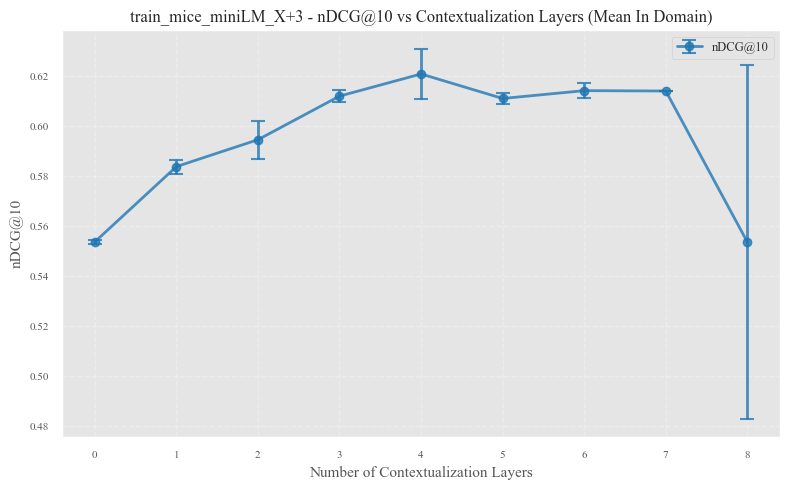


Aggregated nDCG@10 Statistics by Contextualization Layers (Mean In Domain):


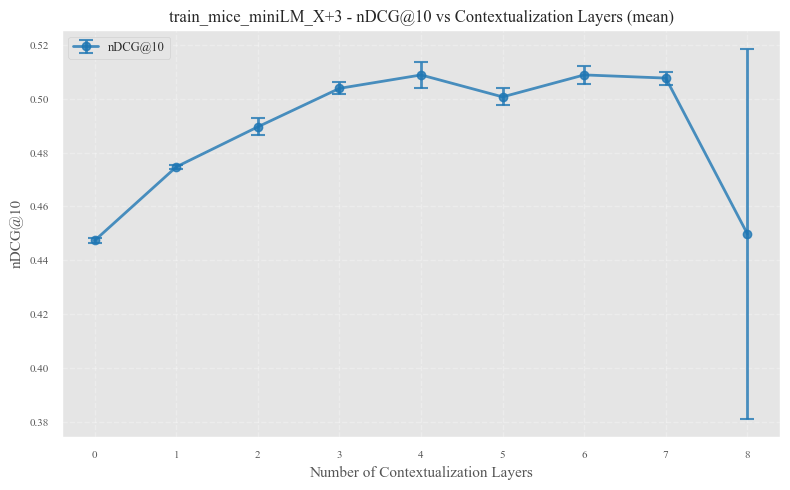


Aggregated nDCG@10 Statistics by Contextualization Layers (mean):


In [33]:
#filter 'n_contextualization_layers' is not null
df = df[df["n_contextualization_layers"].notnull()]
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"

print(f"{len(datasets)} unique datasets : {datasets}")
print(f"unique losses : {list(df['loss'].unique())}")
print(f"Backbones : {list(df['base'].unique())}")

# plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers

# Ensure numeric conversion
df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")

# Plot for each dataset
for dataset_name in ["Mean In Domain", "mean"]:
    dataset_df = df[df["dataset"] == dataset_name].copy()
    if len(dataset_df) == 0:
        print(f"No data found for dataset: {dataset_name}")
        continue
    
    # Group by n_contextualization_layers and compute aggregated statistics
    grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
        mean_nDCG=(metric_mean, "mean"),
        std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
        count=(metric_mean, "count")
    ).reset_index()

    grouped = grouped.sort_values("n_contextualization_layers")

    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        grouped["n_contextualization_layers"],
        grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="o-",
        markersize=6,
        linewidth=2,
        capsize=5,
        capthick=1.5,
        color="#1f77b4",
        ecolor="#1f77b4",
        alpha=0.8,
        label="nDCG@10"
    )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{xp} - {metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    plt.tight_layout()
    plt.show()
    # Display grouped results
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    # display(grouped)

# Ablations

## Booleans Ablation

In [3]:
# Main table
import pandas as pd
from IPython.display import display, HTML

xps = [
    "train_mice_miniLM_bools",
]


def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None


raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)


# Define regex patterns for tags
tags = {
    "base": r"base=(.*)_global",
    "global_cls_token": r"global_cls_token=(.*)_mask_cls_to_doc",
    "mask_query_to_cls": r"mask_query_to_cls=(.*)_loss",
    "mask_cls_to_doc": r"mask_cls_to_doc=(.*)_mask",
}

# rm row without "scorer" tag
df = df[df["scorer"].notna()]
# Split "scorer" into separate columns using the regex patterns
for tag_name, pattern in tags.items():
    df[tag_name] = df["scorer"].apply(lambda x: get_tag(x, pattern))


# Ensure the boolean columns are boolean type
bool_cols = ["global_cls_token", "mask_query_to_cls", "mask_cls_to_doc"]
for col in bool_cols:
    df[col] = df[col].map({"True": True, "False": False})

datasets = list(df["dataset"].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
# print(f"unique losses : {list(df["loss"].unique())}")
# print(f"Backbones : {list(df["base"].unique())}")


display(HTML(df.iloc[0:5].to_html()))

9 unique datasets : ['Mean In Domain', 'fiqa', 'mean', 'msmarco_dev', 'nfcorpus', 'scifact', 'touche', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,first_stage,scorer,base,global_cls_token,mask_query_to_cls,mask_cls_to_doc
3,Mean In Domain,0.767267,2.837472e-05,0.842783,2.380488e-05,0.626333,4.908775e-06,0.612717,1.168059e-05,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=False_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,False,False
4,Mean In Domain,0.768283,1.560529e-06,0.846000,0.000000e+00,0.626450,9.338594e-07,0.613767,3.555358e-06,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=False_mask_query_to_cls=True_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,True,False
5,Mean In Domain,0.758600,4.999275e-07,0.843983,1.027278e-06,0.619367,1.494240e-05,0.608267,1.351999e-05,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=True_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,False,True
6,Mean In Domain,0.759467,1.682005e-05,0.837083,5.570655e-10,0.617517,3.466987e-06,0.603983,2.800545e-06,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=True_mask_query_to_cls=True_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,True,True
7,Mean In Domain,0.758700,5.780196e-06,0.838750,3.472464e-07,0.624617,9.392436e-08,0.613217,7.605629e-07,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=True_mask_cls_to_doc=False_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,True,False,False


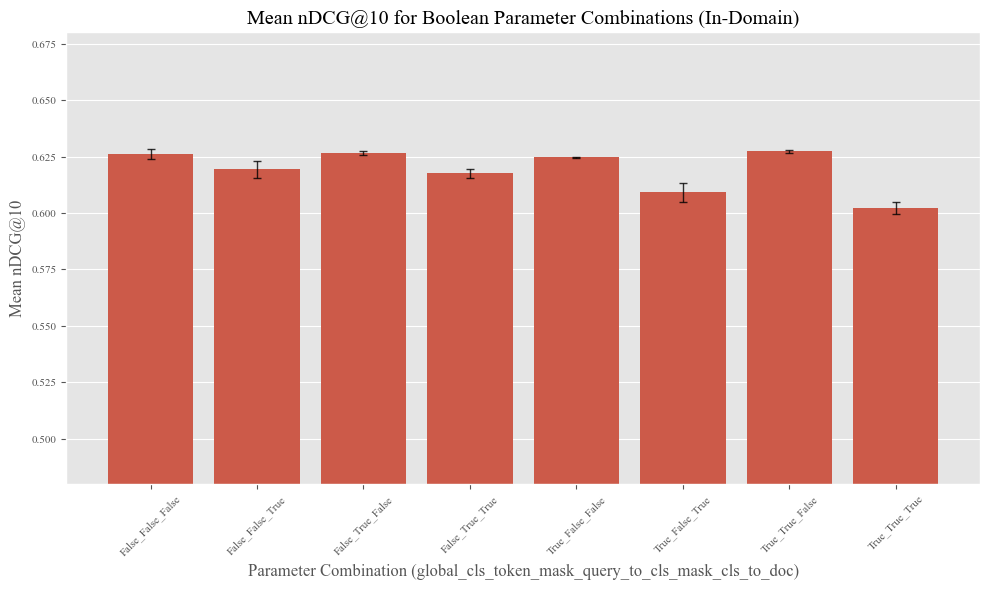

,global_cls_token,mask_query_to_cls,mask_cls_to_doc,mean_nDCG,mean_var,std_nDCG,combination
0,False,False,False,0.626333,4.908775e-06,0.002216,False_False_False
1,False,False,True,0.619367,1.494240e-05,0.003866,False_False_True
2,False,True,False,0.626450,9.338594e-07,0.000966,False_True_False
3,False,True,True,0.617517,3.466987e-06,0.001862,False_True_True
4,True,False,False,0.624617,9.392436e-08,0.000306,True_False_False
5,True,False,True,0.609117,1.820036e-05,0.004266,True_False_True
6,True,True,False,0.627283,5.338608e-07,0.000731,True_True_False
7,True,True,True,0.602150,6.600400e-06,0.002569,True_True_True


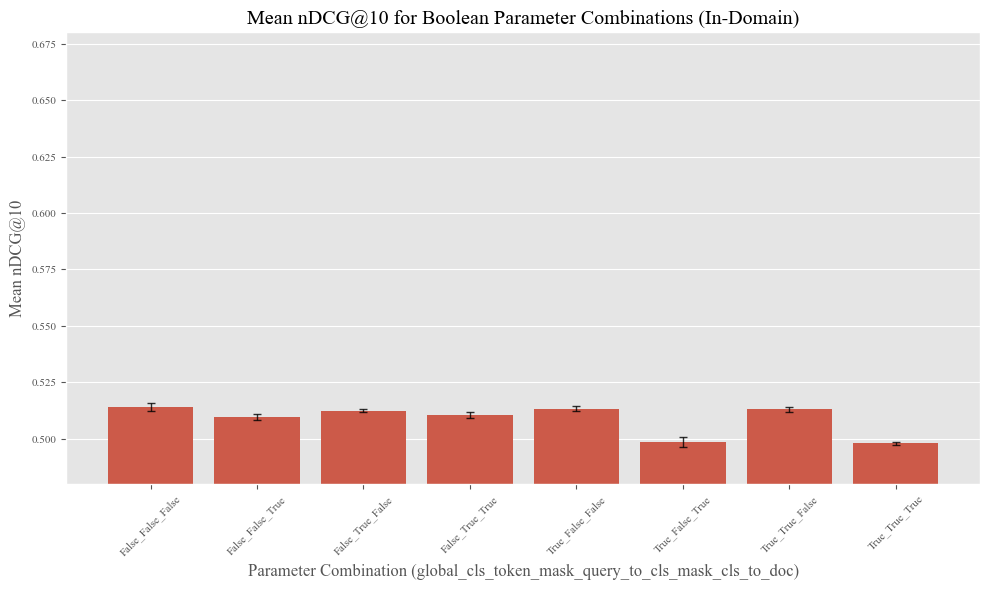

,global_cls_token,mask_query_to_cls,mask_cls_to_doc,mean_nDCG,mean_var,std_nDCG,combination
0,False,False,False,0.514000,2.948883e-06,0.001717,False_False_False
1,False,False,True,0.509779,2.086638e-06,0.001445,False_False_True
2,False,True,False,0.512550,2.449979e-07,0.000495,False_True_False
3,False,True,True,0.510393,1.751026e-06,0.001323,False_True_True
4,True,False,False,0.513407,1.594301e-06,0.001263,True_False_False
5,True,False,True,0.498457,5.028981e-06,0.002243,True_False_True
6,True,True,False,0.513157,1.103660e-06,0.001051,True_True_False
7,True,True,True,0.498000,4.718444e-07,0.000687,True_True_True


In [4]:
# Plot in-domain nDCG@10_mean for each combination of boolean params

import matplotlib.pyplot as plt

for dataset in ["Mean In Domain", "mean"]:
    # Filter for in-domain dataset (assuming msmarco_dev is in-domain)
    in_domain_df = df[df["dataset"] == dataset].copy()

    # Group by the boolean combinations and compute mean of nDCG@10_mean and mean of nDCG@10_var
    grouped = (
        in_domain_df.groupby(bool_cols)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )

    # Compute std as sqrt of mean variance
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    # Create a combination label
    grouped["combination"] = grouped[bool_cols].astype(str).agg("_".join, axis=1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(data=grouped, x="combination", y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title("Mean nDCG@10 for Boolean Parameter Combinations (In-Domain)")
    ax.set_xlabel(
        "Parameter Combination (global_cls_token_mask_query_to_cls_mask_cls_to_doc)"
    )
    ax.set_ylabel("Mean nDCG@10")
    plt.xticks(rotation=45)
    plt.ylim(0.48, 0.68)
    plt.tight_layout()
    plt.show()

    # Display the grouped data
    display(grouped)

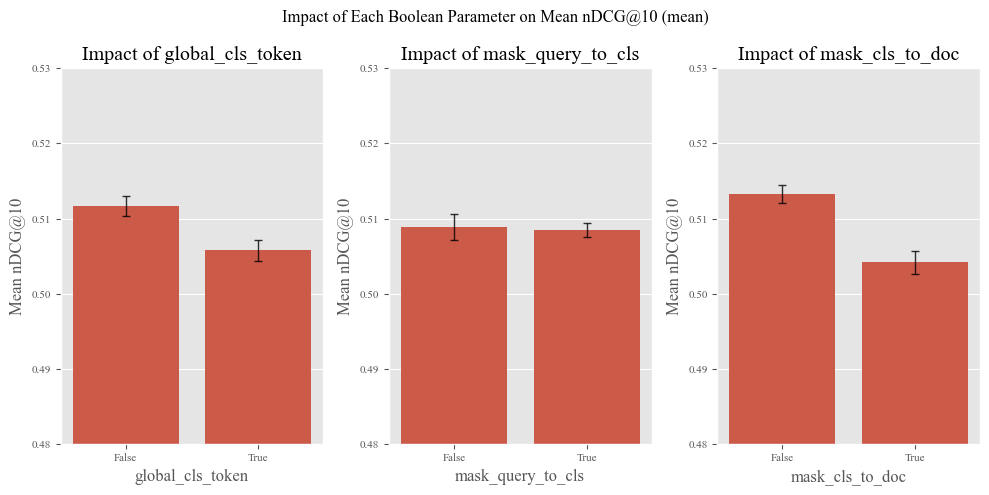

In [5]:
# Plot impact of each boolean parameter separately

# Create subplots for each boolean parameter
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(
    "Impact of Each Boolean Parameter on Mean nDCG@10 ({dataset})".format(
        dataset=dataset
    )
)

grouped_dfs = []
for ax, param in zip(axes, bool_cols):
    grouped = (
        in_domain_df.groupby(param)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    sns.barplot(data=grouped, x=param, y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title(f"Impact of {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean nDCG@10")
    ax.set_ylim(0.48, 0.53)

    grouped_dfs.append(grouped)

plt.tight_layout()
plt.show()